In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('demand_forecasting.csv')
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [4]:
df.shape

(76000, 16)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  str    
 1   Store ID            76000 non-null  str    
 2   Product ID          76000 non-null  str    
 3   Category            76000 non-null  str    
 4   Region              76000 non-null  str    
 5   Inventory Level     76000 non-null  int64  
 6   Units Sold          76000 non-null  int64  
 7   Units Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather Condition   76000 non-null  str    
 11  Promotion           76000 non-null  int64  
 12  Competitor Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  str    
 14  Epidemic            76000 non-null  int64  
 15  Demand              76000 non-null  int64  
dtypes: float64(2), 

In [6]:
df['Date'] = pd.to_datetime(df['Date'])

In [7]:
cols = ['Category','Region','Discount','Weather Condition','Promotion','Seasonality','Epidemic']
for col in cols:
    print(df[col].value_counts())

Category
Groceries      30400
Furniture      13680
Clothing       12160
Toys           10640
Electronics     9120
Name: count, dtype: int64
Region
North    30400
South    15200
East     15200
West     15200
Name: count, dtype: int64
Discount
10    23298
0     17126
5     16918
15     6245
25     6222
20     6191
Name: count, dtype: int64
Weather Condition
Cloudy    24360
Sunny     22980
Rainy     17500
Snowy     11160
Name: count, dtype: int64
Promotion
0    51000
1    25000
Name: count, dtype: int64
Seasonality
Winter    21000
Spring    18400
Summer    18400
Autumn    18200
Name: count, dtype: int64
Epidemic
0    60800
1    15200
Name: count, dtype: int64


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isna().sum().sum()

np.int64(0)

In [10]:
df.describe().round(2)

,Date,Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Competitor Pricing,Epidemic,Demand
count,76000,76000.00,76000.00,76000.00,76000.00,76000.00,76000.00,76000.00,76000.0,76000.00
mean,2023-01-15 12:00:00,301.06,88.83,89.09,67.73,9.09,0.33,69.45,0.2,104.32
min,2022-01-01 00:00:00,0.00,0.00,0.00,4.74,0.00,0.00,4.29,0.0,4.00
25%,2022-07-09 18:00:00,136.00,58.00,0.00,32.00,5.00,0.00,32.62,0.0,71.00
50%,2023-01-15 12:00:00,227.00,84.00,0.00,64.50,10.00,0.00,65.70,0.0,100.00
75%,2023-07-24 06:00:00,408.00,114.00,121.00,95.83,10.00,1.00,97.93,0.0,133.00
max,2024-01-30 00:00:00,2267.00,426.00,1616.00,228.03,25.00,1.00,261.22,1.0,430.00
std,NaN,226.51,43.99,162.40,39.38,7.48,0.47,40.94,0.4,46.96


In [11]:
df.describe(include='object').T

/tmp/ipykernel_78837/1760094569.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object').T


,count,unique,top,freq
Store ID,76000,5,S001,15200
Product ID,76000,20,P0001,3800
Category,76000,5,Groceries,30400
Region,76000,4,North,30400
Weather Condition,76000,4,Cloudy,24360
Seasonality,76000,4,Winter,21000


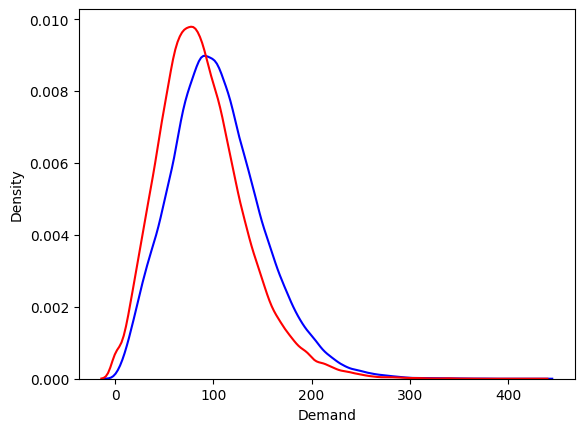

In [12]:
sns.kdeplot(df['Demand'],color='blue')
sns.kdeplot(df['Units Sold'],color='red')
sns.set_theme(style='whitegrid')

In [13]:
# Date column modification
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Weekday'] = df['Date'].dt.day_name()

In [14]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Day,Weekday
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115,2022,1,1,Saturday
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229,2022,1,1,Saturday
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157,2022,1,1,Saturday
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52,2022,1,1,Saturday
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59,2022,1,1,Saturday


In [15]:
df['Discounted Price'] = df['Price'] - (df['Price'] * (df['Discount'] / 100))

In [16]:
df['Sell Through Rate'] = df['Units Sold'] / df['Inventory Level']

In [17]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Day,Weekday,Discounted Price,Sell Through Rate
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,85.73,Winter,0,115,2022,1,1,Saturday,69.084,0.523077
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,...,92.02,Winter,0,229,2022,1,1,Saturday,68.136,1.000000
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,...,60.08,Winter,0,157,2022,1,1,Saturday,56.646,0.461538
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,...,85.19,Winter,0,52,2022,1,1,Saturday,78.867,0.323741
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,...,51.63,Winter,0,59,2022,1,1,Saturday,54.410,0.427632


In [18]:
df.groupby('Category')['Demand'].agg(['mean','sum','std']).sort_values(by='sum')

,mean,sum,std
Category,,,
Electronics,97.482018,889036,40.557859
Toys,92.606955,985338,46.170390
Furniture,73.581140,1006590,32.336141
Clothing,112.619737,1369456,41.022968
Groceries,120.976447,3677684,48.362730


In [19]:
df['Demand'].rolling(window=7).mean()

0              NaN
1              NaN
2              NaN
3              NaN
4              NaN
           ...    
75995    87.000000
75996    95.428571
75997    94.571429
75998    98.857143
75999    95.428571
Name: Demand, Length: 76000, dtype: float64

### Industry level Analysis code

In [20]:
# resample() -- Group your data by time periods (daily, weekly, monthly)

# resample — monthly demand trend per category
df.set_index('Date').groupby('Category').resample('ME')['Demand'].sum()

Category  Date      
Clothing  2022-01-31    62524
          2022-02-28    59037
          2022-03-31    52905
          2022-04-30    52184
          2022-05-31    54551
                        ...  
Toys      2023-09-30    43009
          2023-10-31    25961
          2023-11-30    41284
          2023-12-31    40074
          2024-01-31    33650
Name: Demand, Length: 125, dtype: int64

In [21]:
# rolling() -- For each row, look back N rows and calculate average

# rolling — 7 day moving average
df.groupby('Category')['Demand'].rolling(7).mean()

Category       
Clothing  1               NaN
          2               NaN
          8               NaN
          25              NaN
          34              NaN
                      ...    
Toys      75945     96.285714
          75982    102.142857
          75995    100.142857
          75996    104.142857
          75999    104.285714
Name: Demand, Length: 76000, dtype: float64

In [22]:
# transform() -- Calculate group-level stats but keep them at the original row level

# transform — add category average back to df
df.groupby('Category')['Demand'].transform('mean')

0         97.482018
1        112.619737
2        112.619737
3         97.482018
4        120.976447
            ...    
75995     92.606955
75996     92.606955
75997    112.619737
75998     73.581140
75999     92.606955
Name: Demand, Length: 76000, dtype: float64

In [23]:
# cut() -- Convert continuous numbers into labeled categories/buckets

# cut — (Binning) segment demand levels
df['Demand_level'] = pd.cut(df['Demand'],
    bins=[0, 73, 97, 120, 427],
    labels=['Low', 'Medium', 'High', 'Very High']
)

In [24]:
# query() — filter only high demand groceries

# Filter rows using a readable string condition — like SQL WHERE clause
df.query("Category == 'Groceries' and Demand > 120")

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,Seasonality,Epidemic,Demand,Year,Month,Day,Weekday,Discounted Price,Sell Through Rate,Demand_level
13,2022-01-01,S001,P0014,Groceries,North,252,121,479,80.13,10,...,Winter,0,165,2022,1,1,Saturday,72.1170,0.480159,Very High
22,2022-01-01,S002,P0003,Groceries,South,187,167,596,95.17,10,...,Winter,0,171,2022,1,1,Saturday,85.6530,0.893048,Very High
28,2022-01-01,S002,P0009,Groceries,South,131,131,260,64.84,10,...,Winter,0,145,2022,1,1,Saturday,58.3560,1.000000,Very High
29,2022-01-01,S002,P0010,Groceries,South,242,118,194,117.17,5,...,Winter,0,195,2022,1,1,Saturday,111.3115,0.487603,Very High
43,2022-01-01,S003,P0004,Groceries,East,203,122,518,26.29,5,...,Winter,0,158,2022,1,1,Saturday,24.9755,0.600985,Very High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75960,2024-01-30,S004,P0001,Groceries,West,342,104,0,11.43,5,...,Winter,0,123,2024,1,30,Tuesday,10.8585,0.304094,Very High
75963,2024-01-30,S004,P0004,Groceries,West,439,151,451,62.88,0,...,Winter,0,132,2024,1,30,Tuesday,62.8800,0.343964,Very High
75966,2024-01-30,S004,P0007,Groceries,West,574,112,0,32.25,10,...,Winter,0,154,2024,1,30,Tuesday,29.0250,0.195122,Very High
75985,2024-01-30,S005,P0006,Groceries,North,266,105,0,72.40,0,...,Winter,0,163,2024,1,30,Tuesday,72.4000,0.394737,Very High


In [25]:
df.groupby('Category')['Demand'].mean()

Category
Clothing       112.619737
Electronics     97.482018
Furniture       73.581140
Groceries      120.976447
Toys            92.606955
Name: Demand, dtype: float64

In [26]:
df.groupby(['Region','Seasonality'])['Demand'].mean()

Region  Seasonality
East    Autumn         106.353297
        Spring         100.168478
        Summer         115.388315
        Winter         104.273571
North   Autumn         103.065797
        Spring          97.399457
        Summer         112.843750
        Winter         102.017738
South   Autumn         104.464560
        Spring         100.328804
        Summer         115.089946
        Winter         107.733095
West    Autumn         100.165385
        Spring          93.219293
        Summer         108.111141
        Winter         100.988810
Name: Demand, dtype: float64

In [27]:
df.groupby('Promotion')['Demand'].mean()

Promotion
0     95.026843
1    123.269400
Name: Demand, dtype: float64

In [28]:
df.pivot_table(values = 'Demand',index = 'Month',columns='Category',aggfunc='mean')

Category,Clothing,Electronics,Furniture,Groceries,Toys
Month,,,,,
1,126.997962,99.519022,75.690821,117.399457,94.242236
2,128.966518,84.184524,61.625992,103.522768,68.885204
3,105.835685,108.120968,84.015233,126.561694,128.273041
4,106.972917,85.916667,63.005556,105.111250,85.753571
5,108.650202,79.577957,56.036738,98.637903,71.756912
6,105.670833,106.922222,79.908333,147.772500,100.825000
7,107.838710,87.418011,66.156810,128.744355,74.366359
8,107.871976,109.733871,83.524194,149.875403,102.794931
9,105.118750,105.015278,81.854630,122.239167,102.722619


Text(0.5, 1.0, 'Demand Distribution')

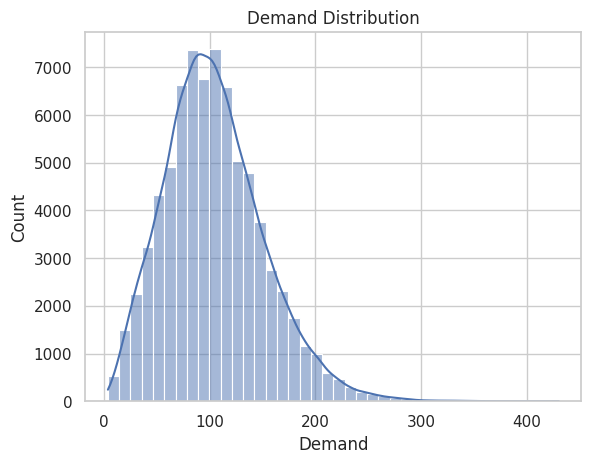

In [29]:
sns.histplot(df['Demand'], kde=True, bins=40)
plt.title("Demand Distribution")

<Axes: xlabel='Inventory Level', ylabel='Units Sold'>

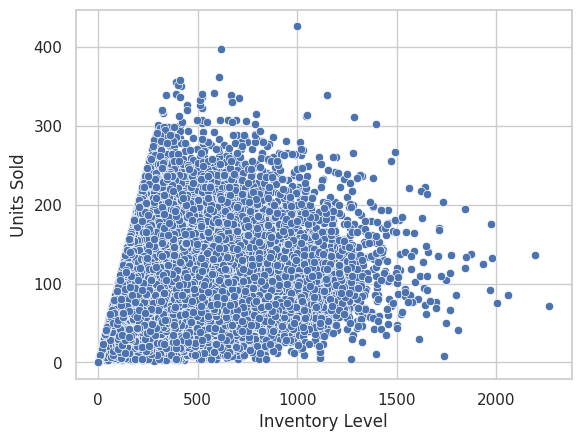

In [30]:
sns.scatterplot(data=df, x='Inventory Level', y='Units Sold')

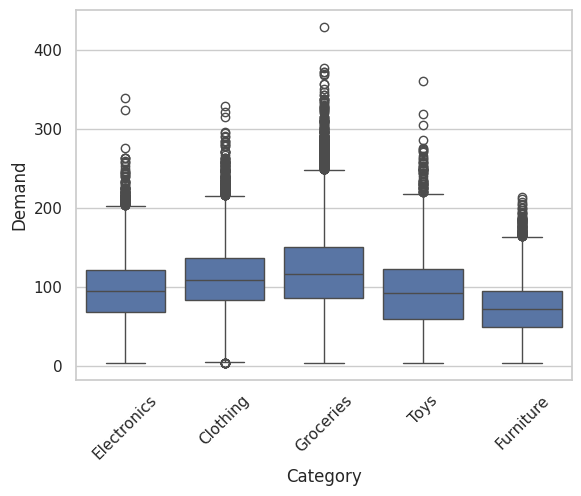

In [31]:
sns.boxplot(data=df, x='Category',y='Demand')
plt.xticks(rotation=45)
plt.show()

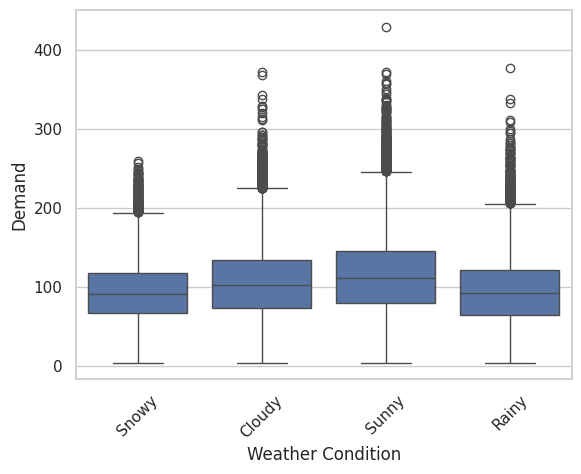

In [32]:
sns.boxplot(data=df, x='Weather Condition',y='Demand')
plt.xticks(rotation=45)
plt.show()

### Timeseries analysis

In [33]:
monthly_demand = df.groupby('Month')['Demand'].mean()

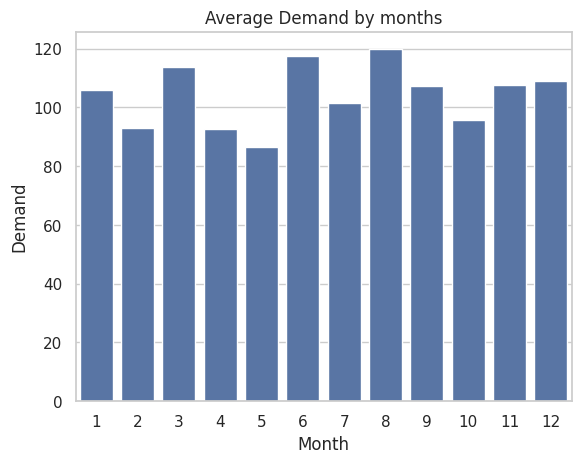

In [34]:
sns.barplot(monthly_demand)
plt.title("Average Demand by months")
plt.show()

In [35]:
daily_demand = df.groupby('Date')['Demand'].sum()

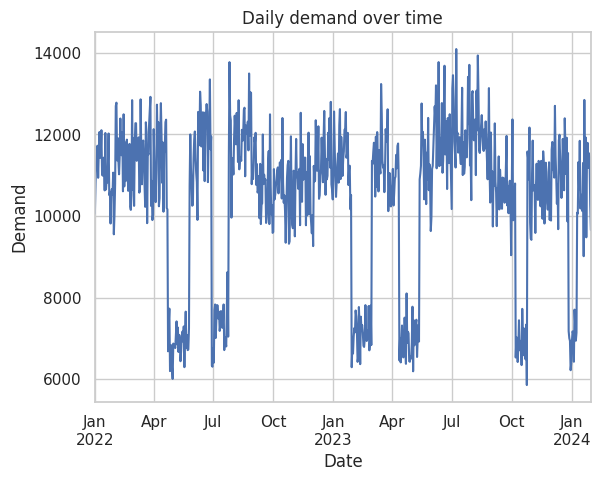

In [36]:
daily_demand.plot()
plt.title('Daily demand over time')
plt.ylabel("Demand")
plt.show()

Text(0.5, 1.0, 'Promotion impact on Demand')

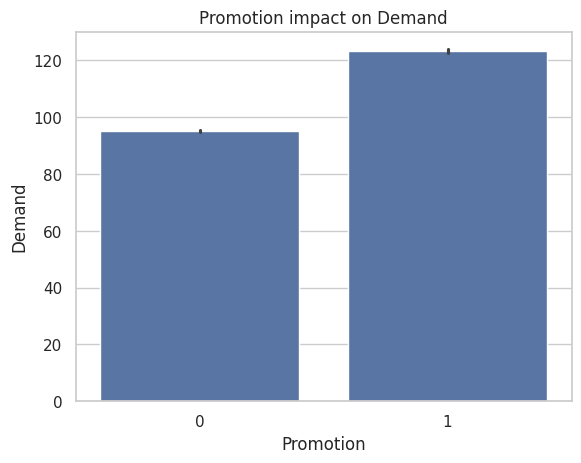

In [37]:
sns.barplot(data=df, x='Promotion',y='Demand')
plt.title("Promotion impact on Demand")

Text(0.5, 1.0, 'Promotion impact on Demand')

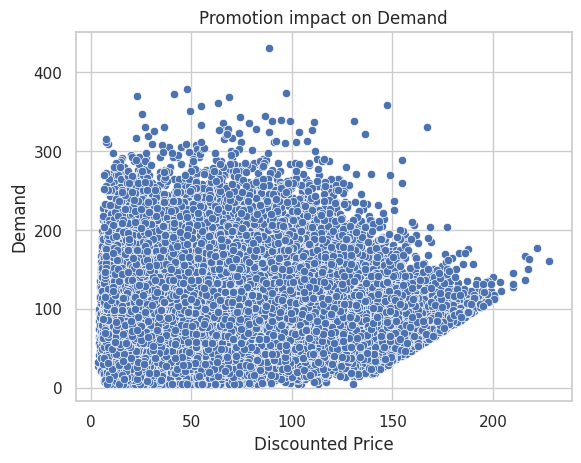

In [38]:
sns.scatterplot(data=df, x='Discounted Price',y='Demand')
plt.title("Promotion impact on Demand")

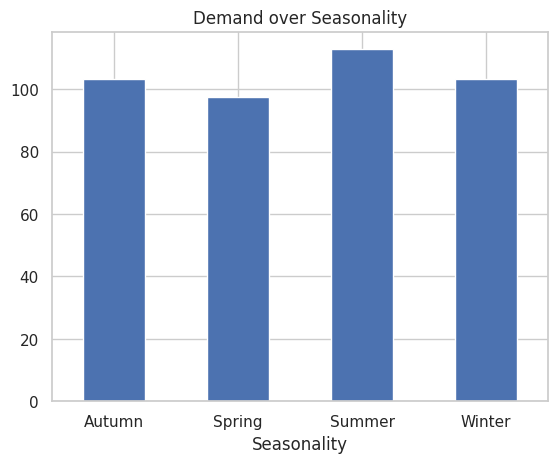

In [39]:
df.groupby('Seasonality')['Demand'].mean().plot(kind='bar',title='Demand over Seasonality')
plt.xticks(rotation='horizontal')
plt.show()

Text(0.5, 1.0, 'Epidemic impact on Demand')

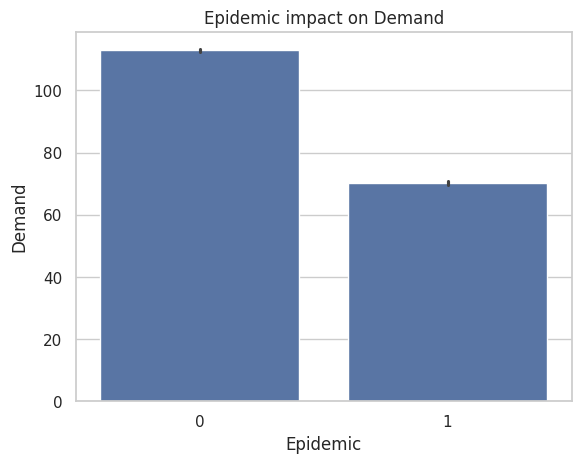

In [40]:
sns.barplot(data=df, x='Epidemic', y='Demand')
plt.title("Epidemic impact on Demand")

In [41]:
df.to_csv('preprocessed_demand_forecasting_data.csv')